# Analytic report over de populariteit van tedtalks
### connectie met db maken door middel van bestaande functie

In [55]:
from db_conn import create_connection
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## is er een verband tussen video tags en populareit van een video?
### data ophalen uit database

In [56]:
conn = create_connection()
cur = conn.cursor()
query = """
SELECT t.id AS tag_id,
       AVG(s.views) AS average_views,
        AVG(s.likes) AS average_likes

FROM tags t
JOIN video_tags vt ON t.id = vt.tag_id
JOIN video_data vd ON vt.video_id = vd.video_id
JOIN statistic s ON s.video_id = vd.video_id
GROUP BY t.id;
"""
cur.execute(query)
results = cur.fetchall()
df = pd.DataFrame(results, columns=['tag_id', 'views', 'likes'])

### een boxplot maken om te zien of de populariteit varieert met tags

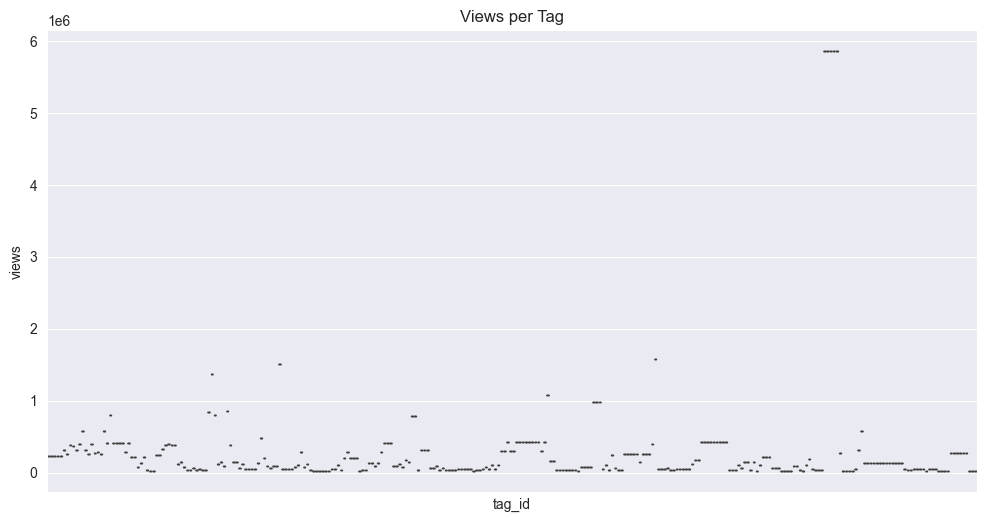

In [57]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='tag_id', y='views', data=df)
plt.xticks([])
plt.title('Views per Tag')
plt.show()

### een scatterplot maken om verband tussen views en likes per tag te zien

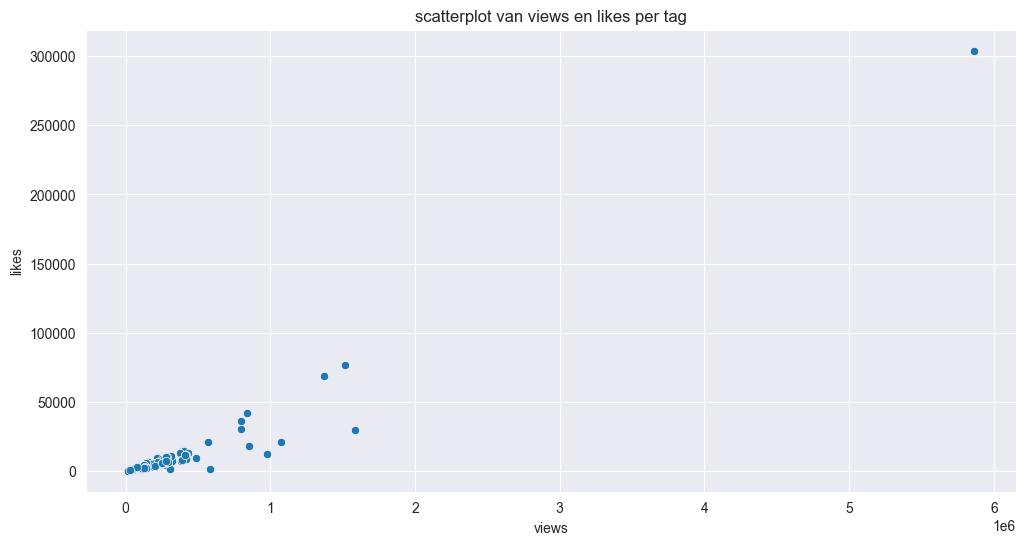

In [58]:
plt.figure(figsize=(12, 6))
sns.scatterplot(x='views (x1.000.000)', y='likes', data=df)
plt.title('scatterplot van views en likes per tag')
plt.show()

### In deze scatterplot is te zien dat de meeste tags erg clusteren. Echter zijn er een aantal uitschieters die veel populairder zijn dan de rest. Ik denk wel dat er een verband is tussen de video tags en de populariteit van de video.

## Kijken of er een verband is tussen category en gemiddelde weergaven per video.
#### eerst de data inladen

In [59]:
query = """
SELECT vd.category_id, AVG(s.views) AS average_views
FROM video_data vd
JOIN statistic s ON vd.video_id = s.video_id
GROUP BY vd.category_id
ORDER BY average_views DESC;
"""
cur.execute(query)
results = cur.fetchall()
df = pd.DataFrame(results, columns=['category', 'average_views'])
print(df)

   category        average_views
0        25  907077.114285714286
1        22  290957.250000000000
2        28  151671.090625000000
3        29  123881.400000000000
4        27   49966.666666666667
5        24   44009.000000000000
6        15   23808.500000000000


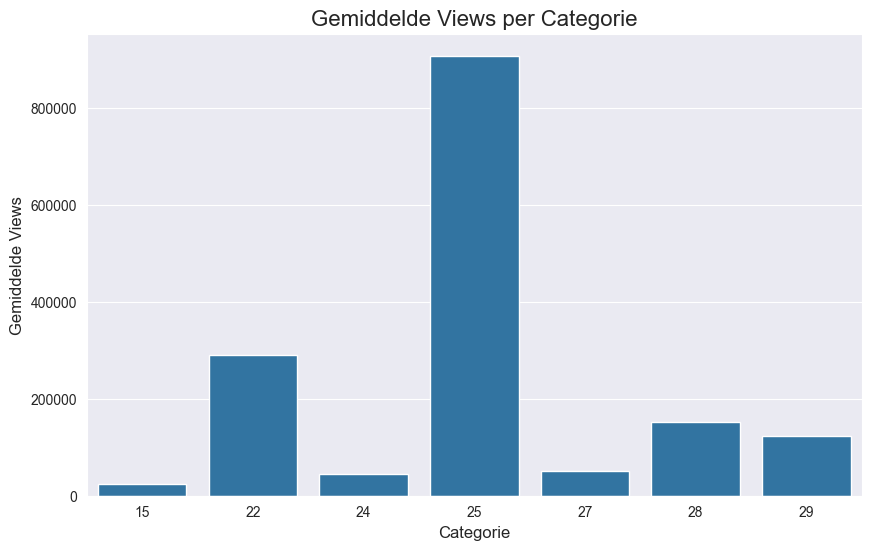

In [60]:
plt.figure(figsize=(10, 6))
sns.barplot(x='category', y='average_views', data=df)

plt.title('gemiddelde views per categorie', fontsize=16)
plt.xlabel('Categorie', fontsize=12)
plt.ylabel('Gemiddelde Views', fontsize=12)
plt.show()

## In deze staafdiagram is te zien dat somige categorien veel populairder zijn dan anderen. Daarom geloof ik dat er dus een sterk verband is tussen de categorien. Daarom ga ik zeker de categorie meenemen bij het bepalen van de populariteit van een video